In [20]:
import numpy as np   
import pandas as pd
import scanpy as sc
import seaborn as sb
from scipy import sparse
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
sc.settings.verbosity = 3         

sc.logging.print_header()            
sc.settings.set_figure_params(dpi=80,   
 dpi_save=300,fontsize=14,format='pdf',
 facecolor='none') 
plt.rcParams['pdf.fonttype'] = 42  
plt.rcParams['font.family'] = 'sans-serif'  
plt.rcParams['font.sans-serif'] = ['Arial']

scanpy==1.9.8 anndata==0.9.2 umap==0.5.6 numpy==1.24.4 scipy==1.10.1 pandas==2.0.3 scikit-learn==1.3.2 statsmodels==0.14.1 igraph==0.11.6 louvain==0.8.2 pynndescent==0.5.13


In [21]:
adata = sc.read_h5ad('GSE172261.h5ad')

In [22]:
adata.obs["Mice"] = "Other"
prefixes = ["M1", "M2", "M3"]

for prefix in prefixes:
    mask = adata.obs.index.str.startswith(prefix)
    adata.obs.loc[mask, "Mice"] = prefix

In [23]:
adata.obs['Sample'] = adata.obs['Sample'].astype('category')
adata.obs['Treatment'] = adata.obs['Treatment'].astype('category')
adata.obs['Site'] = adata.obs['Site'].astype('category')
adata.obs['batch'] = adata.obs['batch'].astype('category')
adata.obs['Celltype_Stroma_Atlas'] = adata.obs['Celltype_Stroma_Atlas'].astype('category')

In [24]:
list(adata.obs["Sample"].cat.categories)

['M1_Distal_DSS',
 'M1_Distal_H2O',
 'M1_Proximal_DSS',
 'M1_Proximal_H2O',
 'M2_Distal_DSS',
 'M2_Distal_H2O',
 'M2_Proximal_DSS',
 'M2_Proximal_H2O',
 'M3_Distal_DSS',
 'M3_Distal_H2O',
 'M3_Proximal_DSS',
 'M3_Proximal_H2O']

In [25]:
adata = adata[
    adata.obs['Celltype_Stroma_Atlas'].isin([
        'Fibroblast 1a',
        'Fibroblast 1b',
        'Fibroblast 1c',
        'Fibroblast 2a',
        'Fibroblast 2b',
        'Fibroblast 2c',
        'Fibroblast 3a',
        'Fibroblast 3b',
    ])
]

C:\Users\wangqiang\AppData\Local\Temp\ipykernel_34828\1815211854.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['mt'] = adata.var_names.str.startswith('mt-')


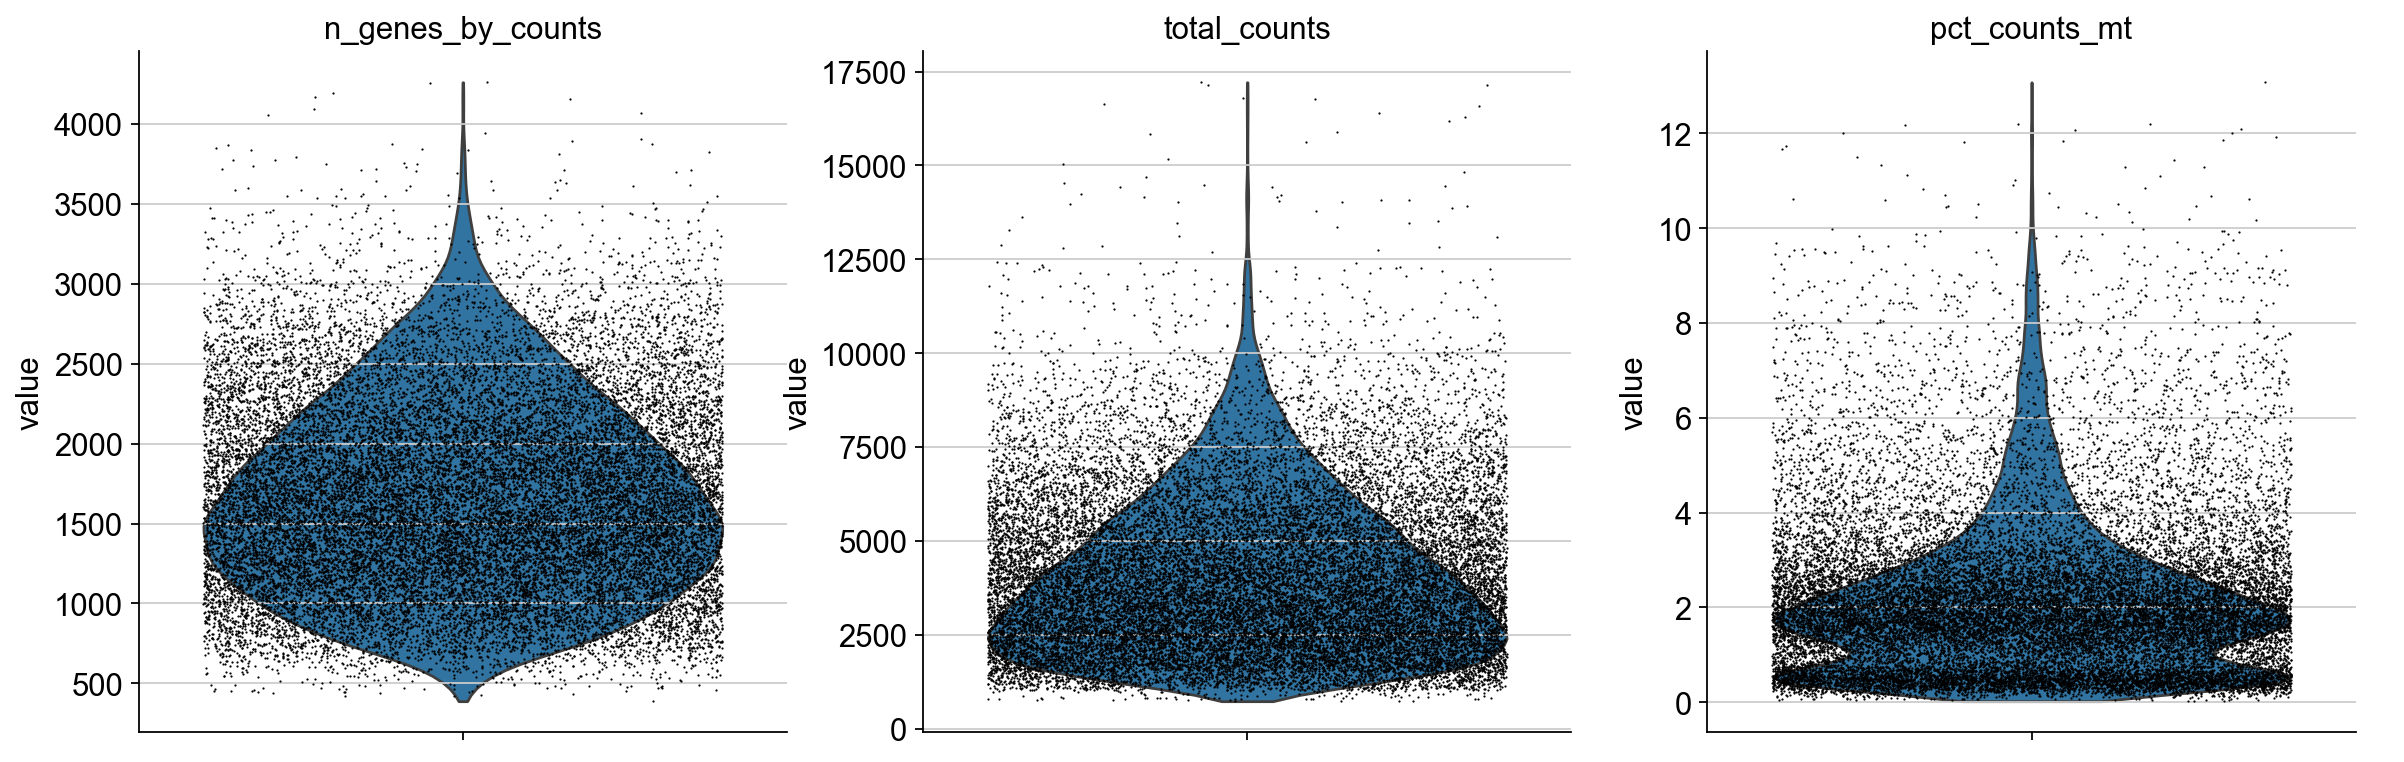

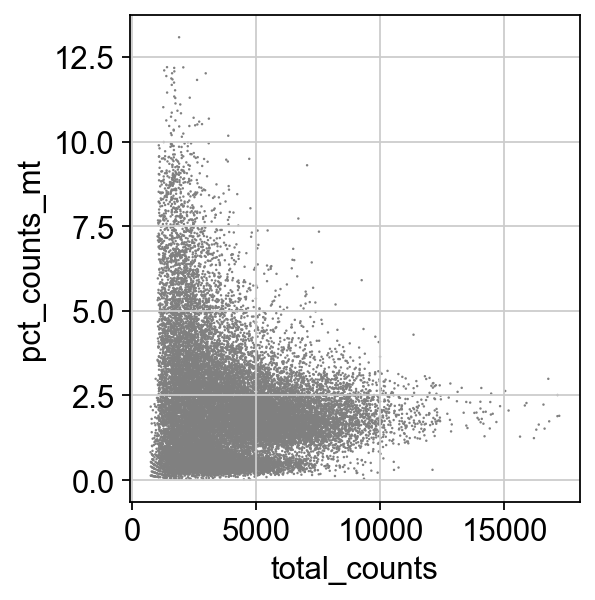

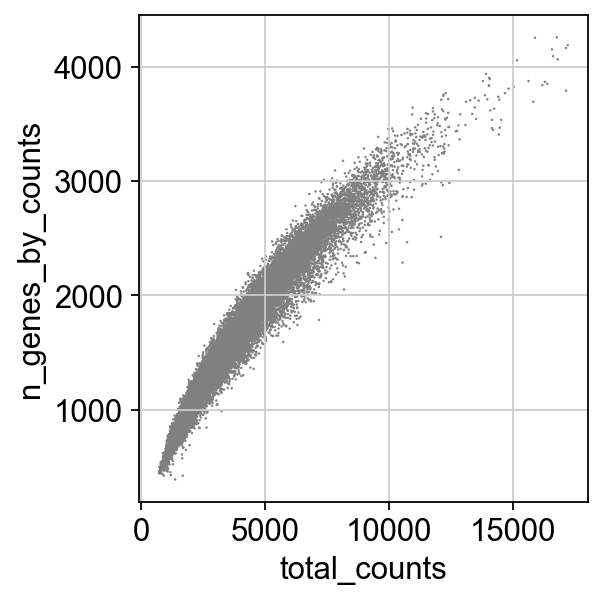

In [26]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)



sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')


sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')




In [27]:

sc.pp.filter_cells(adata, min_genes=800) 

sc.pp.filter_genes(adata, min_cells=3) 

adata = adata[adata.obs.n_genes_by_counts < 4000, :]

adata = adata[adata.obs.total_counts < 10000, :]

adata = adata[adata.obs.pct_counts_mt < 10, :]


filtered out 1315 cells that have less than 800 genes expressed
filtered out 1126 genes that are detected in less than 3 cells


In [28]:
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata) 

c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)


In [29]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5,batch_key='batch',n_top_genes=2000)

adata.raw = adata 
adata = adata[:, adata.var.highly_variable] 


If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [30]:
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])  
sc.pp.scale(adata, max_value=10) 

regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use
    finished (0:00:31)


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:09)


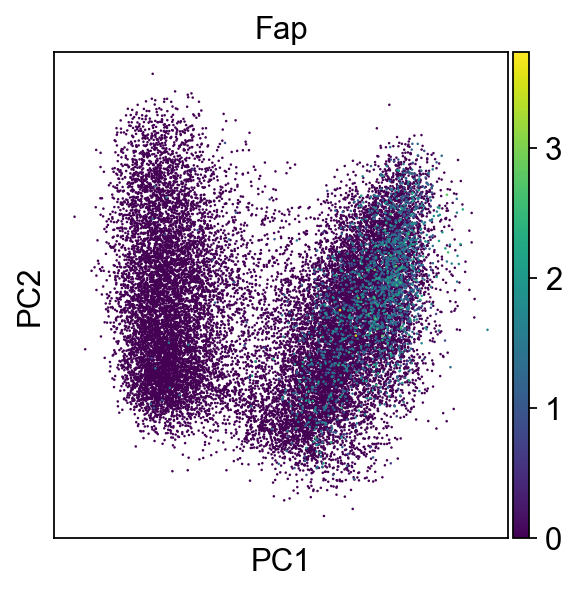

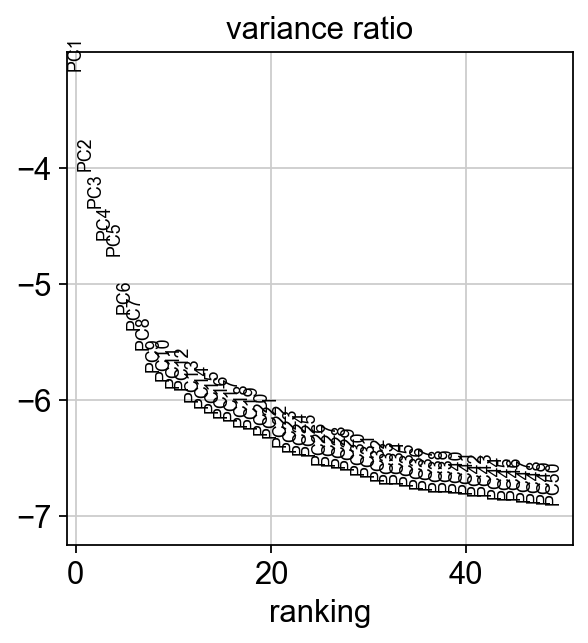

In [31]:
sc.tl.pca(adata, svd_solver='arpack')

sc.pl.pca(adata, color='Fap')

sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [32]:
adata = adata[adata.obs['Treatment'] == 'H2O']

In [ ]:
import harmonypy as hm
dfd = ["batch",'Mice']
harmony_out = hm.run_harmony(adata.obsm['X_pca'], adata.obs,dfd, max_iter_harmony = 50)  

2026-07-14 17:09:48,878 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-07-14 17:09:54,933 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-07-14 17:09:55,023 - harmonypy - INFO - Iteration 1 of 50
2026-07-14 17:09:59,412 - harmonypy - INFO - Iteration 2 of 50
2026-07-14 17:10:03,540 - harmonypy - INFO - Iteration 3 of 50
2026-07-14 17:10:07,636 - harmonypy - INFO - Converged after 3 iterations


In [34]:
adata.write("GSE172261_PCA_harmony.h5ad")